In [90]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
data= fetch_california_housing()
df= pd.DataFrame(data.data, columns= data.feature_names)
df["Target"]= data.target

In [92]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
13248,3.6219,29.0,4.698234,1.017657,1710.0,2.744783,34.11,-117.65,1.76600
8008,4.8393,36.0,6.248062,1.005168,1138.0,2.940568,33.85,-118.11,2.16300
14043,2.6777,35.0,4.036566,1.050874,1308.0,2.079491,32.76,-117.14,1.46400
8875,13.8556,52.0,8.948148,1.077778,810.0,3.000000,34.05,-118.49,5.00001
12914,2.7740,22.0,5.114024,1.107471,1870.0,2.450852,38.61,-121.32,1.90200


In [93]:
X= df.iloc[:, :-1]
y= df.iloc[:, -1]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Single Decision Tree 

In [95]:
model1= DecisionTreeRegressor(random_state=42)

In [96]:
cv_model1= cross_val_score(model1, X_train, y_train, cv=5) 
print(np.round(cv_model1, 2))
print("Avg CV Score:", np.round(np.mean(cv_model1), 2))

[0.59 0.58 0.63 0.59 0.64]
Avg CV Score: 0.61


In [97]:
model1.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [98]:
y_pred1= model1.predict(X_test)
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred1})
print(result)

        Actual  Predicted
20046  0.47700    0.41400
3024   0.45800    1.20300
15663  5.00001    5.00001
20484  2.18600    2.17000
9814   2.78000    2.25700
...        ...        ...
15362  2.63300    2.07000
16623  2.66800    1.40000
18086  5.00001    5.00001
2144   0.72300    0.66000
3665   1.51500    2.17200

[4128 rows x 2 columns]


In [99]:
print("Mean Squared Error:", np.round(mean_squared_error(y_test, y_pred1), 2))
print("R2 Score:", np.round(r2_score(y_test, y_pred1), 2))

Mean Squared Error: 0.5
R2 Score: 0.62


#### Bagging Ensemble

In [100]:
model2= BaggingRegressor(
    estimator= DecisionTreeRegressor(random_state= 42), n_estimators= 50, random_state= 42, n_jobs= -1, max_samples= 0.8
)

# n_jobs=1 → use 1 core (slow)
# n_jobs=2 → use 2 cores
# n_jobs=-1 → use ALL cores available on your system

In [101]:
cv_model2= cross_val_score(model2, X_train, y_train, cv=5) 
print(np.round(cv_model2, 2))
print("Avg CV Score:", np.round(np.mean(cv_model2), 2))

[0.8  0.79 0.81 0.8  0.8 ]
Avg CV Score: 0.8


In [102]:
model2.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [103]:
y_pred2= model2.predict(X_test)
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred2})
print(result)

        Actual  Predicted
20046  0.47700   0.484180
3024   0.45800   0.741940
15663  5.00001   4.759886
20484  2.18600   2.491380
9814   2.78000   2.264100
...        ...        ...
15362  2.63300   2.180260
16623  2.66800   2.058460
18086  5.00001   4.679188
2144   0.72300   0.702740
3665   1.51500   1.666780

[4128 rows x 2 columns]


In [104]:
print("Mean Squared Error:", np.round(mean_squared_error(y_test, y_pred2), 2))
print("R2 Score:", np.round(r2_score(y_test, y_pred2), 2))

Mean Squared Error: 0.26
R2 Score: 0.8


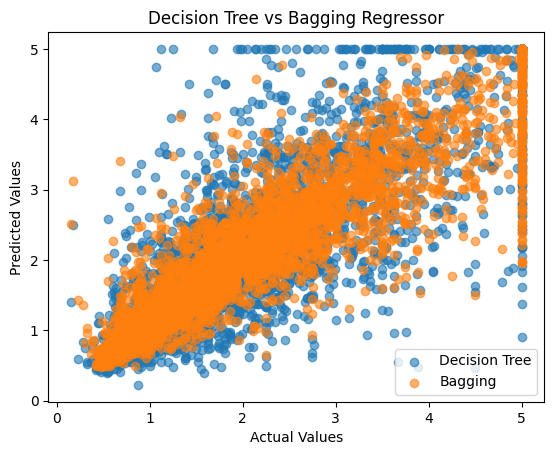

In [105]:
plt.scatter(y_test, y_pred1, alpha= 0.6)
plt.scatter(y_test, y_pred2, alpha= 0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend(["Decision Tree", "Bagging"])
plt.title("Decision Tree vs Bagging Regressor")
plt.show()

#### Bagging with different algorithms

In [106]:
estimators= {
    "SVR": make_pipeline(StandardScaler(),SVR()),
    "KNNR": make_pipeline(StandardScaler(), KNeighborsRegressor())
}


SVR
[0.74 0.74 0.75 0.75 0.73]
Avg CV Score: 0.74
Mean Squared Error: 0.36
R2 Score: 0.73


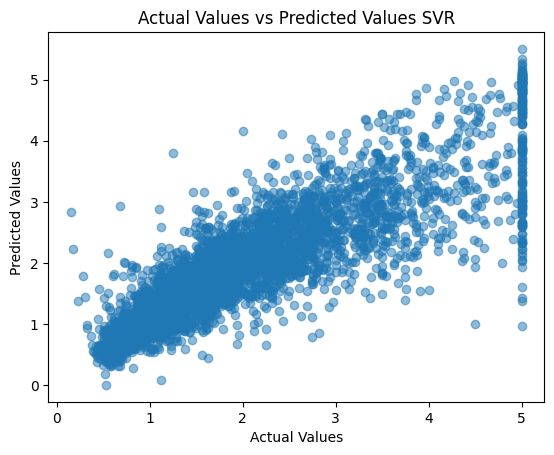


KNNR
[0.7  0.71 0.72 0.72 0.71]
Avg CV Score: 0.71
Mean Squared Error: 0.41
R2 Score: 0.69


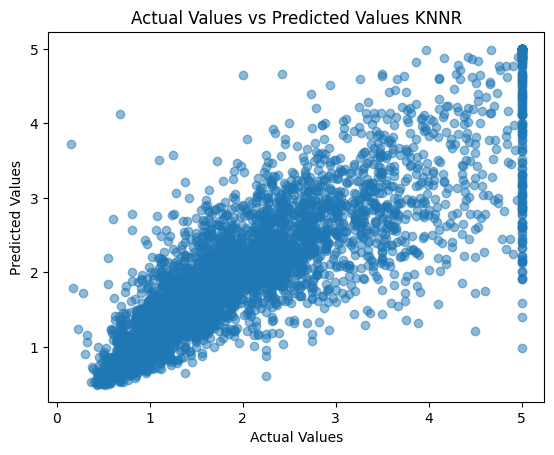

In [107]:
for name, estimator in estimators.items():
    model3= BaggingRegressor(estimator= estimator, random_state= 42, n_estimators= 30, max_samples= 0.8, bootstrap= True, n_jobs= -1)

    print(f"\n{name}")
    cv_model3= cross_val_score(model3, X_train, y_train, cv=5) 
    print(np.round(cv_model3, 2))
    print("Avg CV Score:", np.round(np.mean(cv_model3), 2))

    model3.fit(X_train, y_train)
    y_pred3= model3.predict(X_test)

    print("Mean Squared Error:", np.round(mean_squared_error(y_test, y_pred3), 2))
    print("R2 Score:", np.round(r2_score(y_test, y_pred3), 2))
    
    plt.figure()
    plt.scatter(y_test, y_pred3, alpha= 0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual Values vs Predicted Values {name}")
    plt.show()